# **English to French Translation using Attention Mechanism with TensorFlow**

## Introduction

This comprehensive guide will teach you how to build a neural machine translation system that translates English text to French using the attention mechanism. We'll implement an encoder-decoder architecture with Luong attention using TensorFlow/Keras.

**Key Components:**
- **Encoder**: Processes the English input sequence using bidirectional LSTM
- **Decoder**: Generates French output sequence using unidirectional LSTM  
- **Attention Mechanism**: Allows decoder to focus on relevant parts of the input

## Prerequisites


### Required Libraries


In [249]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import re
import os
import time
from sklearn.model_selection import train_test_split
import unicodedata

### Installation


In [250]:
!pip install tensorflow>=2.8.0
!pip install numpy pandas matplotlib scikit-learn

## Dataset Preparation



### Option 1: Download English-French Dataset


In [251]:
import urllib.request
import zipfile
import os

def download_and_extract_dataset():
    """Download English-French dataset from Anki"""
    url = "http://www.manythings.org/anki/fra-eng.zip"
    zip_path = "fra-eng.zip"

    # Download dataset
    urllib.request.urlretrieve(url, zip_path)

    # Extract dataset
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall('.')

    # Clean up
    os.remove(zip_path)
    print("Dataset downloaded and extracted successfully!")

# Uncomment to download
download_and_extract_dataset()

Dataset downloaded and extracted successfully!


## Text Preprocessing


### Text Cleaning and Normalization


In [252]:
def unicode_to_ascii(s):
    return ''.join(c for c in unicodedata.normalize('NFD', s)
                   if unicodedata.category(c) != 'Mn')


def preprocess_sentence(w):
    w = unicode_to_ascii(w.lower().strip())
    # Add spaces around punctuation
    w = re.sub(r"([?.!,¿])", r" \1 ", w)
    w = re.sub(r'\s+', ' ', w)
    # Keep letters and punctuation
    w = re.sub(r"[^a-zA-Z?.!,¿<>/0-9]+", ' ', w)
    w = w.strip()
    w = '<start> ' + w + ' <end>'
    return w

def create_dataset(path='fra.txt', num_examples=30000):
    """Load parallel English-French (fra.txt from manythings) and preprocess."""
    lines = open(path, encoding='utf-8').read().strip().split('\n')
    en_sentences = []
    fr_sentences = []

    for line in lines[:num_examples]:
        parts = line.split('\t')
        if len(parts) >= 2:
            en = preprocess_sentence(parts[0])
            fr = preprocess_sentence(parts[1])
            en_sentences.append(en)
            fr_sentences.append(fr)

    return en_sentences, fr_sentences


### Tokenization and Vocabulary Creation


In [253]:
class LanguageTokenizer:
    def __init__(self, oov_token='<unk>'):
        self.word2idx = {}
        self.idx2word = {}
        self.vocab = []
        self.oov_token = oov_token

    def create_tokenizer(self, sentences, specials=('<pad>', '<start>', '<end>', '<unk>')):
        vocab_set = set()
        for sentence in sentences:
            for w in sentence.split():
                vocab_set.add(w)

        # Add special tokens first
        self.vocab = list(specials) + sorted(vocab_set - set(specials))

        # Create mappings
        self.word2idx = {w: i for i, w in enumerate(self.vocab)}
        self.idx2word = {i: w for w, i in self.word2idx.items()}

    def encode(self, sentence, max_length):
        seq = [self.word2idx.get(w, self.word2idx.get(self.oov_token)) for w in sentence.split()]
        seq = seq[:max_length]
        if len(seq) < max_length:
            seq += [self.word2idx['<pad>']] * (max_length - len(seq))
        return seq

    def decode(self, sequence):
        words = [self.idx2word.get(idx, self.oov_token) for idx in sequence if idx != self.word2idx.get('<pad>')]
        return ' '.join(words)


def create_tokenizers_and_datasets(en_sentences, fr_sentences):
    en_tokenizer = LanguageTokenizer()
    fr_tokenizer = LanguageTokenizer()

    en_tokenizer.create_tokenizer(en_sentences)
    fr_tokenizer.create_tokenizer(fr_sentences)

    en_max_length = max(len(s.split()) for s in en_sentences)
    fr_max_length = max(len(s.split()) for s in fr_sentences)

    print(f'English max length: {en_max_length}')
    print(f'French max length: {fr_max_length}')
    print(f'English vocab size: {len(en_tokenizer.word2idx)}')
    print(f'French vocab size: {len(fr_tokenizer.word2idx)}')

    input_tensor = np.array([en_tokenizer.encode(s, en_max_length) for s in en_sentences])
    target_tensor = np.array([fr_tokenizer.encode(s, fr_max_length) for s in fr_sentences])

    return input_tensor, target_tensor, en_tokenizer, fr_tokenizer, en_max_length, fr_max_length



In [254]:
# Example usage:
en_sentences = ["hello world", "how are you", "good morning"]
fr_sentences = ["bonjour monde", "comment allez vous", "bonjour"]

# Call the function - THIS is when the prints will happen
input_tensor, target_tensor, en_tok, fr_tok, en_max, fr_max = create_tokenizers_and_datasets(
    en_sentences,
    fr_sentences
)

English max length: 3
French max length: 3
English vocab size: 11
French vocab size: 9


## Model Architecture


### Encoder Class


In [255]:
class Encoder(tf.keras.layers.Layer):
    def __init__(self, vocab_size, embedding_dim, enc_units, batch_size):
        super(Encoder, self).__init__()
        self.batch_size = batch_size
        self.enc_units = enc_units
        self.embedding = tf.keras.layers.Embedding(vocab_size, embedding_dim)
        # return_state=True for LSTM returns h and c for forward and backward
        self.bi_lstm = tf.keras.layers.Bidirectional(
            tf.keras.layers.LSTM(enc_units,
                                 return_sequences=True,
                                 return_state=True,
                                 recurrent_initializer='glorot_uniform'),
            merge_mode='sum'
        )

    def call(self, x, initial_states):
        x = self.embedding(x)
        # initial_states must be list of four tensors [f_h, f_c, b_h, b_c]
        outputs_and_states = self.bi_lstm(x, initial_state=initial_states)
        # outputs_and_states = (outputs, f_h, f_c, b_h, b_c)
        enc_output = outputs_and_states[0]
        f_h = outputs_and_states[1]
        f_c = outputs_and_states[2]
        b_h = outputs_and_states[3]
        b_c = outputs_and_states[4]

        # combine forward & backward states by sum (since merge_mode='sum')
        state_h = tf.keras.layers.Add()([f_h, b_h])
        state_c = tf.keras.layers.Add()([f_c, b_c])

        return enc_output, state_h, state_c

    def initialize_hidden_state(self):
        # returns 4 zero states for forward and backward (h and c)
        return [tf.zeros((self.batch_size, self.enc_units)) for _ in range(4)]



### Attention Mechanism (Luong Attention)


In [256]:
class LuongAttention(tf.keras.layers.Layer):
    def __init__(self, units):
        super(LuongAttention, self).__init__()
        self.W = tf.keras.layers.Dense(units)

    def call(self, query, values):
        # query shape: (batch, dec_units)
        # values shape: (batch, seq_len, enc_units)

        # Transform values: (batch, seq_len, units)
        values_transformed = self.W(values)

        # Expand query: (batch, units, 1)
        query_expanded = tf.expand_dims(query, axis=-1)  # (batch, units, 1)

        # Compute score: (batch, seq_len, 1) via matmul of values_transformed and query_expanded
        # First transpose values_transformed to (batch, seq_len, units) already ready for matmul
        score = tf.matmul(values_transformed, query_expanded)  # (batch, seq_len, 1)

        attention_weights = tf.nn.softmax(score, axis=1)  # normalize over seq_len

        # context: weighted sum over values (original encoder outputs)
        context_vector = attention_weights * values  # (batch, seq_len, enc_units)
        context_vector = tf.reduce_sum(context_vector, axis=1)  # (batch, enc_units)

        # squeeze attention weights to (batch, seq_len)
        attention_weights = tf.squeeze(attention_weights, axis=-1)

        return context_vector, attention_weights


### Decoder Class


In [257]:
class Decoder(tf.keras.layers.Layer):
    def __init__(self, vocab_size, embedding_dim, dec_units, batch_size):
        super(Decoder, self).__init__()
        self.batch_size = batch_size
        self.dec_units = dec_units
        self.vocab_size = vocab_size

        # Layers
        self.embedding = tf.keras.layers.Embedding(vocab_size, embedding_dim)
        self.lstm = tf.keras.layers.LSTM(dec_units,
                                         return_sequences=True,
                                         return_state=True,
                                         recurrent_initializer='glorot_uniform')
        self.attention = LuongAttention(dec_units)
        # Combine context and LSTM output
        self.Wc = tf.keras.layers.Dense(dec_units, activation='tanh')
        self.fc = tf.keras.layers.Dense(vocab_size)

    def call(self, x, hidden, enc_output):
        # x: (batch, 1)
        x = self.embedding(x)  # (batch, 1, embedding_dim)

        output, state_h, state_c = self.lstm(x, initial_state=hidden)
        # output: (batch, 1, dec_units)
        output = tf.reshape(output, (-1, output.shape[2]))  # (batch, dec_units)

        # Attention expects query shape (batch, dec_units)
        context_vector, attention_weights = self.attention(output, enc_output)  # (batch, enc_units), (batch, seq_len)

        # Combine context and output
        combined = tf.concat([context_vector, output], axis=-1)  # (batch, enc_units+dec_units)
        combined = tf.expand_dims(combined, 1)  # (batch, 1, ...)

        wc_out = self.Wc(combined)  # (batch, 1, dec_units)
        wc_out = tf.reshape(wc_out, (-1, wc_out.shape[2]))  # (batch, dec_units)

        logits = self.fc(wc_out)  # (batch, vocab_size)

        return logits, [state_h, state_c], attention_weights


### Complete Model Class


In [258]:
class EncoderDecoderModel(tf.keras.Model):
    def __init__(self, enc_vocab_size, dec_vocab_size, embedding_dim, enc_units, dec_units, batch_size):
        super(EncoderDecoderModel, self).__init__()
        self.encoder = Encoder(enc_vocab_size, embedding_dim, enc_units, batch_size)
        self.decoder = Decoder(dec_vocab_size, embedding_dim, dec_units, batch_size)
        self.batch_size = batch_size # Store batch size


    def call(self, inputs, training=True):
        enc_input, dec_input = inputs

        # Initialize encoder hidden state based on the model's batch size
        enc_hidden = self.encoder.initialize_hidden_state()


        enc_output, enc_h, enc_c = self.encoder(enc_input, enc_hidden)
        dec_hidden = [enc_h, enc_c]

        predictions = []
        attention_weights_list = []

        # Teacher forcing across decoder input sequence
        for t in range(dec_input.shape[1]):
            dec_input_t = tf.expand_dims(dec_input[:, t], 1)
            logits, dec_hidden, attn = self.decoder(dec_input_t, dec_hidden, enc_output)
            predictions.append(logits)
            attention_weights_list.append(attn)

        # stack to (batch, dec_seq_len, vocab)
        predictions = tf.stack(predictions, axis=1)
        return predictions, attention_weights_list


## Training


### Loss Function and Optimizer


In [259]:
def loss_function(real, pred):
    loss_object = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True, reduction='none')
    loss_ = loss_object(real, pred)
    mask = tf.cast(tf.not_equal(real, 0), dtype=loss_.dtype)
    loss_ *= mask
    return tf.reduce_sum(loss_) / tf.reduce_sum(mask)


optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)


### Training Step


In [260]:
@tf.function
def train_step(inp, targ, model):
    with tf.GradientTape() as tape:
        # Teacher forcing: feed target tokens (except last) as input
        dec_input = targ[:, :-1]
        dec_target = targ[:, 1:]

        predictions, _ = model([inp, dec_input], training=True)
        # predictions shape: (batch, dec_seq_len, vocab)

        loss = loss_function(dec_target, predictions)

    variables = model.trainable_variables
    gradients = tape.gradient(loss, variables)
    gradients, _ = tf.clip_by_global_norm(gradients, 5.0)
    optimizer.apply_gradients(zip(gradients, variables))
    return loss

### Training Loop


In [261]:
def train_model(model, dataset, epochs, steps_per_epoch, checkpoint_prefix=None):
    for epoch in range(epochs):
        start = time.time()
        total_loss = 0.0

        for (batch, (inp, targ)) in enumerate(dataset.take(steps_per_epoch)):
            batch_loss = train_step(inp, targ, model)
            total_loss += batch_loss

            if batch % 100 == 0:
                print(f'Epoch {epoch+1} Batch {batch} Loss {batch_loss.numpy():.4f}')

        print(f'Epoch {epoch+1} Loss {total_loss/steps_per_epoch:.4f}')
        print(f'Time taken for 1 epoch {time.time()-start:.2f} sec')

        if checkpoint_prefix and (epoch + 1) % 5 == 0:
            model.save_weights(os.path.join(checkpoint_prefix, f'ckpt-{epoch+1}.weights.h5'))
            print(f'Checkpoint saved at epoch {epoch+1}')


## Inference and Translation


### Translation Function


In [262]:
def translate(sentence, model, en_tokenizer, fr_tokenizer, max_length_en, max_length_fr):
    sentence_proc = preprocess_sentence(sentence)
    inputs = np.array([en_tokenizer.encode(sentence_proc, max_length_en)])
    inputs = tf.convert_to_tensor(inputs)

    result_words = []

    # Initialize encoder hidden state for inference batch size (1)
    enc_hidden = model.encoder.initialize_hidden_state()

    enc_out, enc_h, enc_c = model.encoder(inputs, enc_hidden)
    dec_hidden = [enc_h, enc_c]

    dec_input = tf.expand_dims([fr_tokenizer.word2idx['<start>']], 0)

    attention_plot = np.zeros((max_length_fr, max_length_en))

    for t in range(max_length_fr):
        predictions, dec_hidden, attention_weights = model.decoder(dec_input, dec_hidden, enc_out)
        # predictions: (batch=1, vocab)
        predicted_id = tf.argmax(predictions[0]).numpy()
        predicted_word = fr_tokenizer.idx2word.get(predicted_id, '<unk>')

        result_words.append(predicted_word)

        # Attention weights shape should be (1, max_length_en) from decoder
        # Squeeze along axis 0 to remove the batch dimension for plotting
        attention_plot[t] = tf.squeeze(attention_weights, axis=0).numpy()


        if predicted_word == '<end>':
            break

        # The predicted ID is fed back into the model
        dec_input = tf.expand_dims([predicted_id], 0)

    return ' '.join(result_words), sentence_proc, attention_plot


def evaluate_translation(sentence, model, en_tokenizer, fr_tokenizer, max_length_en, max_length_fr):
    result, processed_sentence, attention_plot = translate(sentence, model, en_tokenizer, fr_tokenizer, max_length_en, max_length_fr)
    print(f'Input: {processed_sentence}')
    print(f'Predicted translation: {result}')
    return result, attention_plot

## Evaluation


### BLEU Score Implementation


In [263]:
# BLEU implementation (simple)
def calculate_bleu_score(reference, candidate, n=4):
    reference_tokens = reference.split()
    candidate_tokens = candidate.split()

    if len(candidate_tokens) == 0:
        return 0.0

    precisions = []
    for i in range(1, n + 1):
        ref_ngrams = Counter([' '.join(reference_tokens[j:j+i]) for j in range(len(reference_tokens) - i + 1)])
        cand_ngrams = Counter([' '.join(candidate_tokens[j:j+i]) for j in range(len(candidate_tokens) - i + 1)])

        if sum(cand_ngrams.values()) == 0:
            precisions.append(0.0)
            continue

        matches = sum((ref_ngrams & cand_ngrams).values())
        total = sum(cand_ngrams.values())
        precision = matches / total
        precisions.append(precision)

    bp = 1.0
    if len(candidate_tokens) < len(reference_tokens) and len(candidate_tokens) > 0:
        bp = math.exp(1 - len(reference_tokens) / len(candidate_tokens))

    if all(p > 0 for p in precisions):
        bleu = bp * math.exp(sum(math.log(p) for p in precisions) / len(precisions))
    else:
        bleu = 0.0

    return bleu * 100


def evaluate_model(model, test_sentences_en, test_sentences_fr, en_tokenizer, fr_tokenizer, max_length_en, max_length_fr):
    total_bleu = 0.0
    num_sentences = len(test_sentences_en)

    for i in range(num_sentences):
        eng = test_sentences_en[i]
        ref_fr = test_sentences_fr[i].replace('<start> ', '').replace(' <end>', '')

        # Correctly unpack all three return values from translate
        pred_fr, processed_eng, attention = translate(eng, model, en_tokenizer, fr_tokenizer, max_length_en, max_length_fr)
        pred_fr = pred_fr.replace('<start> ', '').replace(' <end>', '')

        bleu = calculate_bleu_score(ref_fr, pred_fr)
        total_bleu += bleu

        if i < 5:
            print(f'English: {eng}')
            print(f'Reference: {ref_fr}')
            print(f'Predicted: {pred_fr}')
            print(f'BLEU Score: {bleu:.2f}')
            print('-' * 50)

    avg_bleu = total_bleu / num_sentences
    print(f'Average BLEU Score: {avg_bleu:.2f}')
    return avg_bleu


## Visualization


### Attention Visualization


In [264]:
# Attention plotting
def plot_attention(attention, sentence, predicted_sentence):
    sentence_tokens = sentence.split()
    predicted_tokens = predicted_sentence.split()

    # truncate attention to actual sizes
    attention_plot = attention[:len(predicted_tokens), :len(sentence_tokens)]

    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(1, 1, 1)
    cax = ax.matshow(attention_plot, cmap='Blues')
    fig.colorbar(cax)

    ax.set_xticklabels([''] + sentence_tokens, rotation=90)
    ax.set_yticklabels([''] + predicted_tokens)

    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

    plt.xlabel('English Input')
    plt.ylabel('French Output')
    plt.title('Attention')
    plt.tight_layout()
    plt.show()


def visualize_attention_for_sentence(sentence, model, en_tokenizer, fr_tokenizer, max_length_en, max_length_fr):
    result, processed_sentence, attention_plot = translate(sentence, model, en_tokenizer, fr_tokenizer, max_length_en, max_length_fr)
    print(f'Input: {processed_sentence}')
    print(f'Prediction: {result}')
    plot_attention(attention_plot, processed_sentence, result)
    return result, attention_plot


## Complete Implementation


### Main Training Script


Loading and preprocessing data...
English max length: 9
French max length: 17
English vocab size: 4337
French vocab size: 7501
Training samples: 24000
Validation samples: 6000
Epoch 1 Batch 0 Loss 8.9228
Epoch 1 Batch 100 Loss 4.5713
Epoch 1 Batch 200 Loss 3.8499
Epoch 1 Batch 300 Loss 3.6629
Epoch 1 Loss 4.1372
Time taken for 1 epoch 81.92 sec
Epoch 2 Batch 0 Loss 3.2517
Epoch 2 Batch 100 Loss 2.7536
Epoch 2 Batch 200 Loss 2.8442
Epoch 2 Batch 300 Loss 2.3956
Epoch 2 Loss 2.8587
Time taken for 1 epoch 32.27 sec
Epoch 3 Batch 0 Loss 2.4314
Epoch 3 Batch 100 Loss 2.6442
Epoch 3 Batch 200 Loss 2.1973
Epoch 3 Batch 300 Loss 2.1378
Epoch 3 Loss 2.2746
Time taken for 1 epoch 32.65 sec
Epoch 4 Batch 0 Loss 1.9226
Epoch 4 Batch 100 Loss 1.9895
Epoch 4 Batch 200 Loss 1.8308
Epoch 4 Batch 300 Loss 1.6088
Epoch 4 Loss 1.8318
Time taken for 1 epoch 32.18 sec
Epoch 5 Batch 0 Loss 1.4616
Epoch 5 Batch 100 Loss 1.4107
Epoch 5 Batch 200 Loss 1.4912
Epoch 5 Batch 300 Loss 1.4722
Epoch 5 Loss 1.4821
Ti

/tmp/ipython-input-644585666.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + sentence_tokens, rotation=90)
/tmp/ipython-input-644585666.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + predicted_tokens)


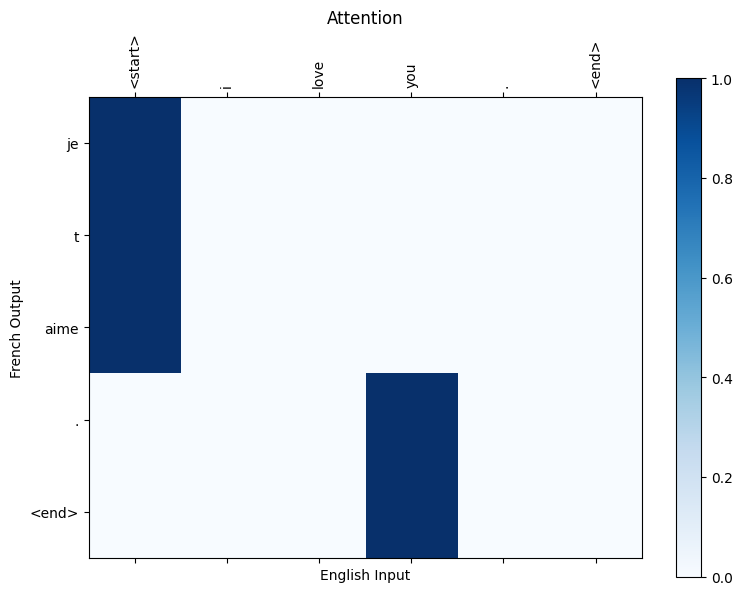


Input: <start> how are you ? <end>
Predicted translation: comment vas tu ? <end>
Input: <start> how are you ? <end>
Prediction: comment vas tu ? <end>


/tmp/ipython-input-644585666.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + sentence_tokens, rotation=90)
/tmp/ipython-input-644585666.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + predicted_tokens)


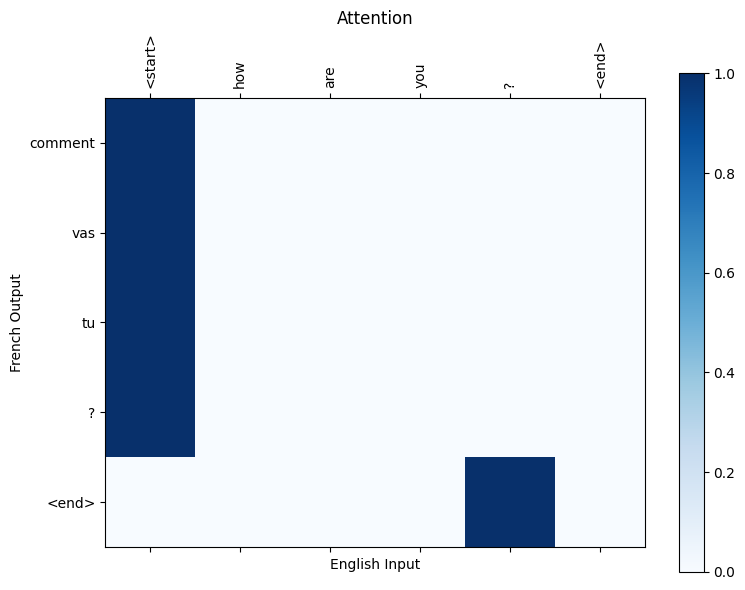


Input: <start> good morning . <end>
Predicted translation: bonjour . <end>
Input: <start> good morning . <end>
Prediction: bonjour . <end>


/tmp/ipython-input-644585666.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + sentence_tokens, rotation=90)
/tmp/ipython-input-644585666.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + predicted_tokens)


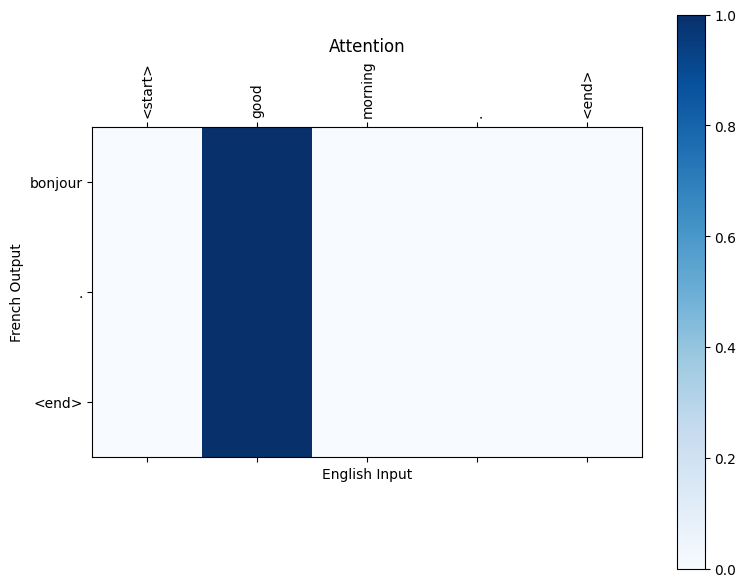


Input: <start> this is a beautiful day . <end>
Predicted translation: c est une belle journee . <end>
Input: <start> this is a beautiful day . <end>
Prediction: c est une belle journee . <end>


/tmp/ipython-input-644585666.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + sentence_tokens, rotation=90)
/tmp/ipython-input-644585666.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + predicted_tokens)


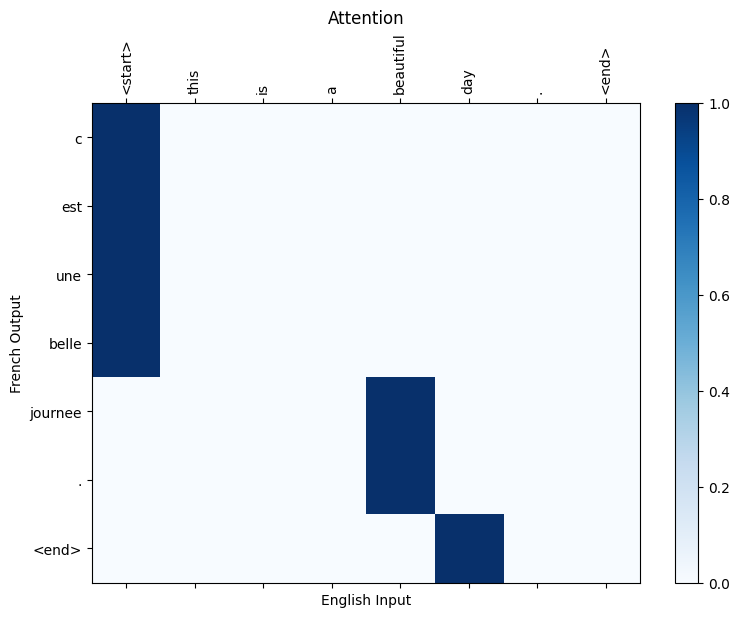


Input: <start> where is the bathroom ? <end>
Predicted translation: ou sont les nouvelles ? <end>
Input: <start> where is the bathroom ? <end>
Prediction: ou sont les nouvelles ? <end>


/tmp/ipython-input-644585666.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + sentence_tokens, rotation=90)
/tmp/ipython-input-644585666.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + predicted_tokens)


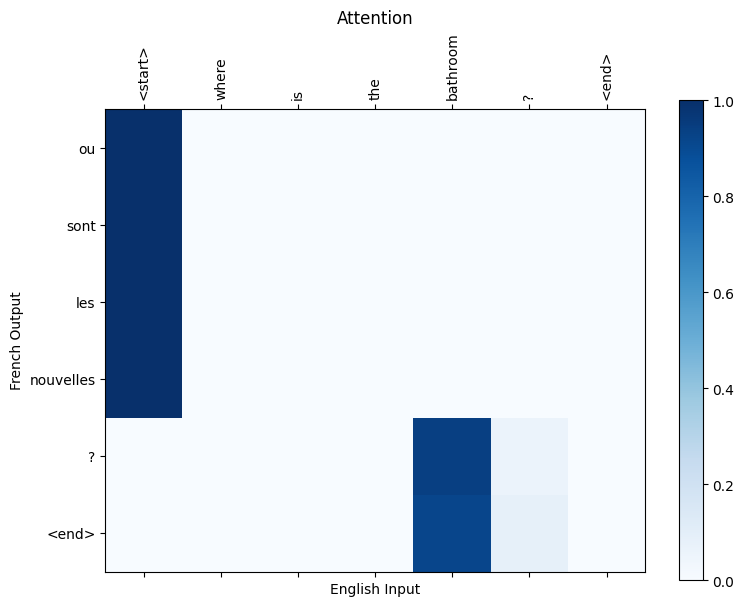



EVALUATING ON VALIDATION SET
English: <start> i m unwell . <end>
Reference: je ne me sens pas bien .
Predicted: je ne suis pas encore debout .
BLEU Score: 0.00
--------------------------------------------------
English: <start> it s a snowstorm . <end>
Reference: c est une tempete de neige .
Predicted: c est un peu de lumiere .
BLEU Score: 0.00
--------------------------------------------------
English: <start> the noes have it . <end>
Reference: le non l emporte .
Predicted: la lumiere est tres .
BLEU Score: 0.00
--------------------------------------------------
English: <start> why did you quit ? <end>
Reference: pourquoi as tu demissionne ?
Predicted: pourquoi es tu arrete ?
BLEU Score: 0.00
--------------------------------------------------
English: <start> tom is sad . <end>
Reference: tom est triste .
Predicted: tom est le gateau .
BLEU Score: 0.00
--------------------------------------------------
Average BLEU Score: 6.05


In [265]:

def main():
    # Hyperparameters
    BATCH_SIZE = 64
    EMBEDDING_DIM = 256
    UNITS = 512
    EPOCHS = 10
    NUM_EXAMPLES = 30000

    print('Loading and preprocessing data...')
    en_sentences, fr_sentences = create_dataset('fra.txt', num_examples=NUM_EXAMPLES)

    input_tensor, target_tensor, en_tokenizer, fr_tokenizer, max_length_en, max_length_fr = create_tokenizers_and_datasets(en_sentences, fr_sentences)

    input_train, input_val, target_train, target_val = train_test_split(input_tensor, target_tensor, test_size=0.2, random_state=42)

    print(f'Training samples: {len(input_train)}')
    print(f'Validation samples: {len(input_val)}')

    BUFFER_SIZE = len(input_train)
    steps_per_epoch = len(input_train) // BATCH_SIZE

    dataset = tf.data.Dataset.from_tensor_slices((input_train, target_train))
    dataset = dataset.shuffle(BUFFER_SIZE).batch(BATCH_SIZE, drop_remainder=True)

    # Create model for training with batch size = BATCH_SIZE
    training_model = EncoderDecoderModel(
        enc_vocab_size=len(en_tokenizer.word2idx),
        dec_vocab_size=len(fr_tokenizer.word2idx),
        embedding_dim=EMBEDDING_DIM,
        enc_units=UNITS,
        dec_units=UNITS,
        batch_size=BATCH_SIZE
    )

    checkpoint_dir = './checkpoints'
    os.makedirs(checkpoint_dir, exist_ok=True)

    train_model(training_model, dataset, EPOCHS, steps_per_epoch, checkpoint_prefix=checkpoint_dir)

    # Save final weights
    final_weights_path = os.path.join(checkpoint_dir, 'final_model.weights.h5')
    training_model.save_weights(final_weights_path)
    print('Training completed and model weights saved!')

    # Create a new model instance for inference with batch size = 1
    inference_model = EncoderDecoderModel(
        enc_vocab_size=len(en_tokenizer.word2idx),
        dec_vocab_size=len(fr_tokenizer.word2idx),
        embedding_dim=EMBEDDING_DIM,
        enc_units=UNITS,
        dec_units=UNITS,
        batch_size=1 # Batch size for inference
    )

    # Build the inference model to load weights
    # You can pass a dummy input with batch size 1 to build it
    dummy_input = tf.zeros((1, max_length_en), dtype=tf.int32)
    dummy_dec_input = tf.zeros((1, max_length_fr), dtype=tf.int32) # Dec input also needs to match max_length_fr for building
    inference_model([dummy_input, dummy_dec_input], training=False)


    # Load the trained weights into the inference model
    inference_model.load_weights(final_weights_path)
    print('Inference model created and weights loaded!')


    # Test translations
    test_sentences = [
        "I love you.",
        "How are you?",
        "Good morning.",
        "This is a beautiful day.",
        "Where is the bathroom?"
    ]

    print('\n' + '='*50)
    print('TESTING TRANSLATIONS')
    print('='*50)
    for sentence in test_sentences:
        # Use the inference_model for translation
        result, attention_plot = evaluate_translation(sentence, inference_model, en_tokenizer, fr_tokenizer, max_length_en, max_length_fr)
        visualize_attention_for_sentence(sentence, inference_model, en_tokenizer, fr_tokenizer, max_length_en, max_length_fr)
        print()

    # Evaluate on a subset of validation set for BLEU
    print('\n' + '='*50)
    print('EVALUATING ON VALIDATION SET')
    print('='*50)

    val_en_sentences = [en_tokenizer.decode(seq) for seq in input_val[:100]]
    val_fr_sentences = [fr_tokenizer.decode(seq) for seq in target_val[:100]]

    # Use the inference_model for evaluation
    avg_bleu = evaluate_model(inference_model, val_en_sentences, val_fr_sentences, en_tokenizer, fr_tokenizer, max_length_en, max_length_fr)


if __name__ == '__main__':
    main()